In [2]:
import pandas as pd
import matplotlib.pyplot as plt
print("Notebook working")

Notebook working


In [52]:
fund = pd.read_csv("../data/raw/fund_master.csv")
nav = pd.read_csv("../data/raw/nav_history.csv")
aum = pd.read_csv("../data/raw/aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/monthly_sip_inflows.csv")
cat = pd.read_csv("../data/raw/category_inflows.csv")
folio = pd.read_csv("../data/raw/industry_folio_count.csv")
perf = pd.read_csv("../data/raw/scheme_performance.csv")
txn = pd.read_csv("../data/raw/investor_transactions.csv")

print("Data Loaded Successfully")


print("\nFund Master")
print(fund.shape)

print("\nNAV History")
print(nav.shape)

print("\nAUM")
print(aum.shape)

print("\nSIP")
print(sip.shape)

print("\nPerformance")
print(perf.shape)

print("\nTransactions")
print((txn.shape)
)

print(nav_history.head())

print(
    nav_history.isnull().sum()
)

fund.info()


print(
    "Duplicate Records"
)

print(
    fund.duplicated().sum()
)

print(
    nav.duplicated().sum()
)
print(
    aum.duplicated().sum()
)
print(
    sip.duplicated().sum()
)
print(
    perf.duplicated().sum()
)
print(
    txn.duplicated().sum()
)

Data Loaded Successfully

Fund Master
(40, 15)

NAV History
(46000, 3)

AUM
(90, 5)

SIP
(48, 6)

Performance
(40, 19)

Transactions
(32778, 13)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
amfi_code    0
date         0
nav          0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expens

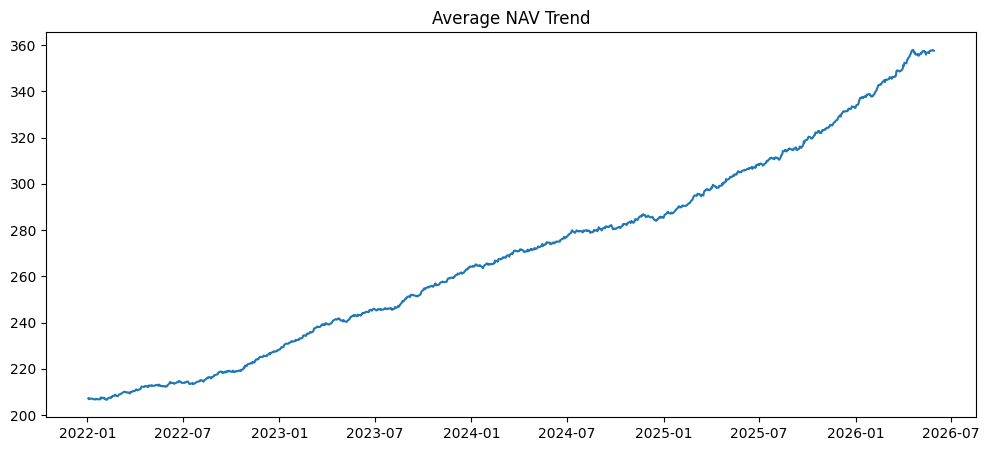

In [14]:
nav["date"] = pd.to_datetime(nav["date"])

sample = nav.groupby("date")["nav"].mean()

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample.values)
plt.title("Average NAV Trend")
plt.show()

In [13]:
from pathlib import Path

for file in Path("../data/raw").glob("*"):
    print(file.name)

aum_by_fund_house.csv
benchmark_indices.csv
category_inflows.csv
fund_master.csv
industry_folio_count.csv
investor_transactions.csv
live_nav_hdfc_top100.csv
monthly_sip_inflows.csv
nav_history.csv
portfolio_holdings.csv
scheme_performance.csv


In [15]:
from pathlib import Path
import os

print(os.getcwd())

c:\Users\saman\OneDrive\Desktop\Fintech_Project\notebooks


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

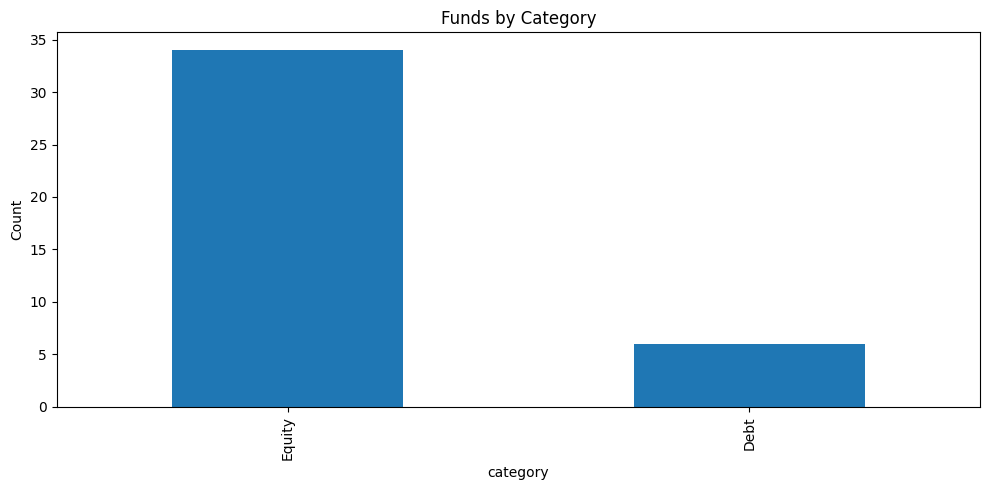

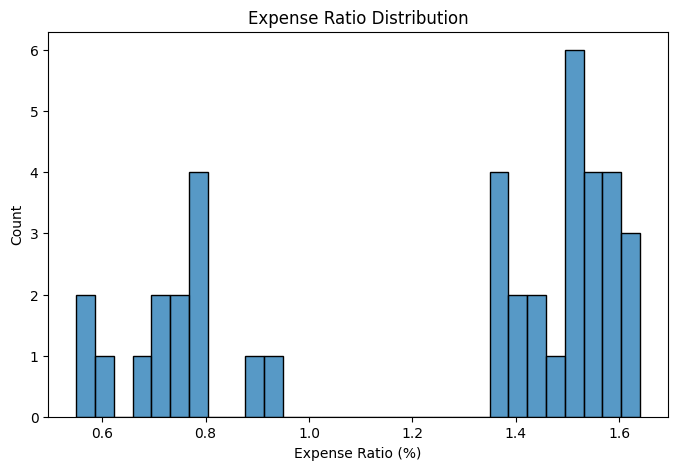

In [47]:
fund["category"].value_counts().plot(
    kind="bar",
    title="Funds by Category"
)

plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Expense Ratio Analysis

plt.figure(figsize=(8,5))

sns.histplot(
    fund["expense_ratio_pct"],
    bins=30
)

plt.title(
    "Expense Ratio Distribution"
)

plt.xlabel(
    "Expense Ratio (%)"
)

plt.show()

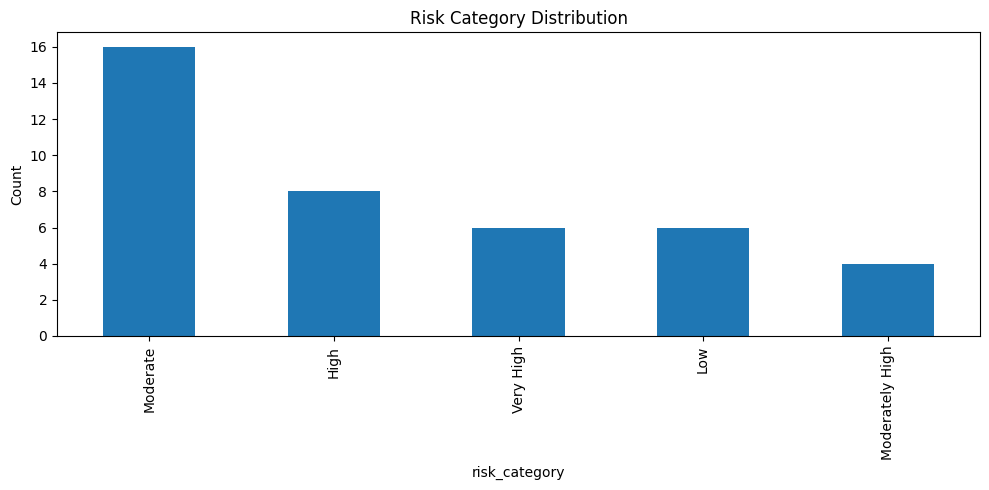

In [20]:
fund["risk_category"].value_counts().plot(
    kind="bar",
    title="Risk Category Distribution"
)

plt.ylabel("Count")
plt.tight_layout()
plt.show()

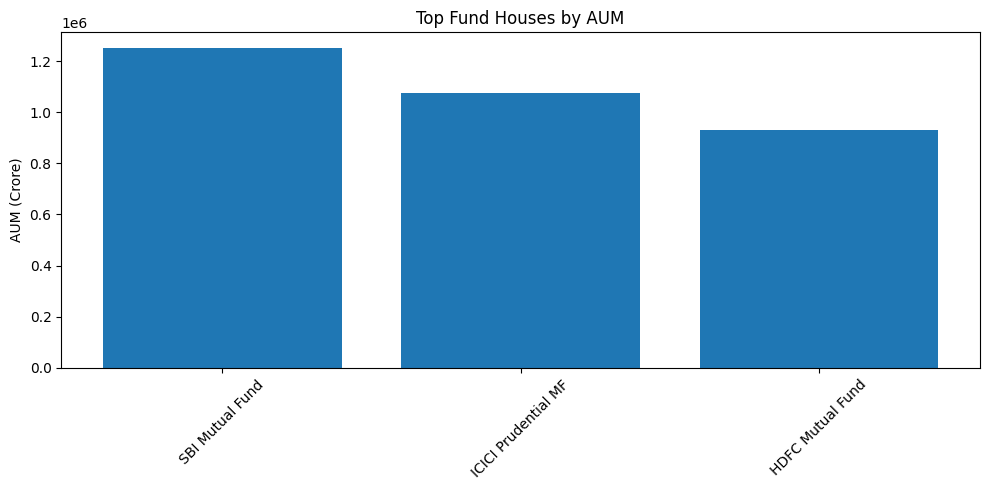

In [21]:
latest = aum.sort_values("aum_crore", ascending=False)

top10 = latest.head(10)

plt.bar(top10["fund_house"], top10["aum_crore"])

plt.xticks(rotation=45)
plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.tight_layout()
plt.show()

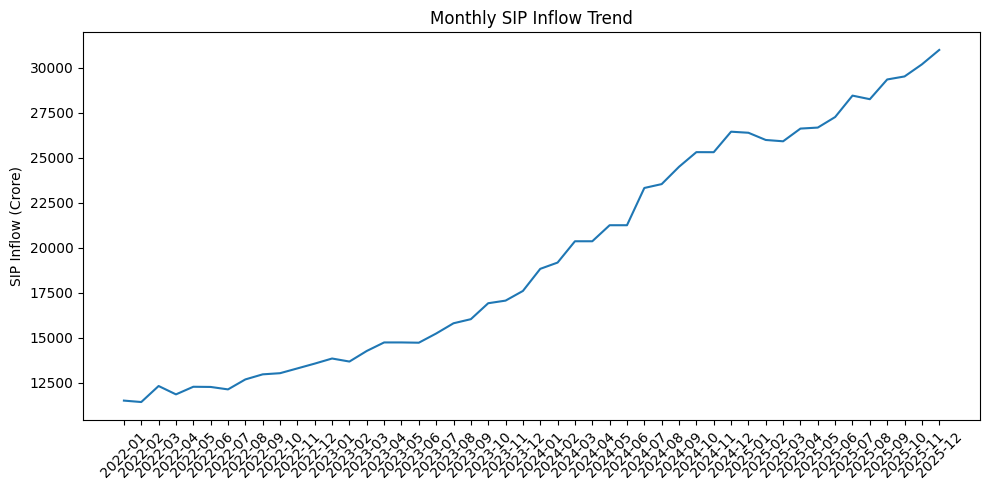

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xticks(rotation=45)
plt.ylabel("SIP Inflow (Crore)")
plt.tight_layout()
plt.show()

In [23]:
print("SIP")
print(sip.columns.tolist())

print("\nCATEGORY")
print(cat.columns.tolist())

print("\nFOLIO")
print(folio.columns.tolist())

print("\nPERFORMANCE")
print(perf.columns.tolist())

print("\nTRANSACTION")
print(txn.columns.tolist())

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

TRANSACTION
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [24]:
fund.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [25]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

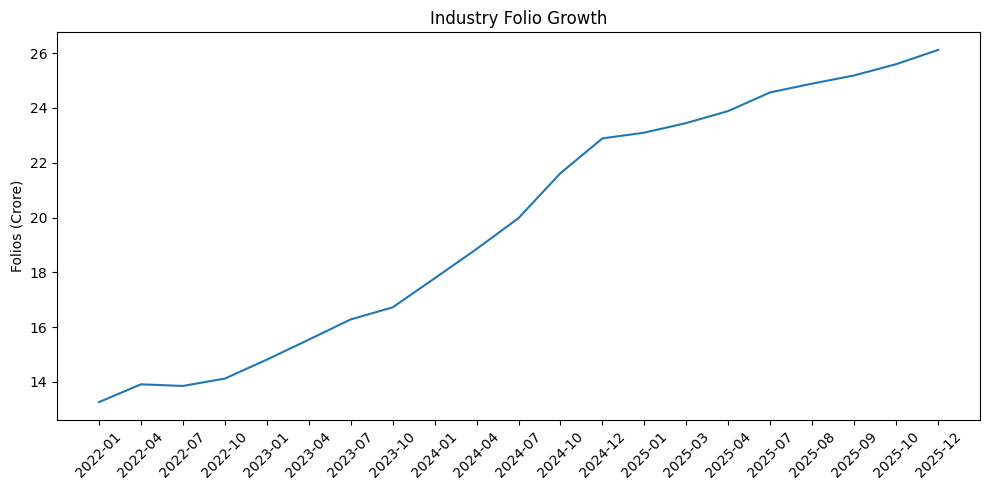

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xticks(rotation=45)
plt.ylabel("Folios (Crore)")
plt.tight_layout()
plt.show()

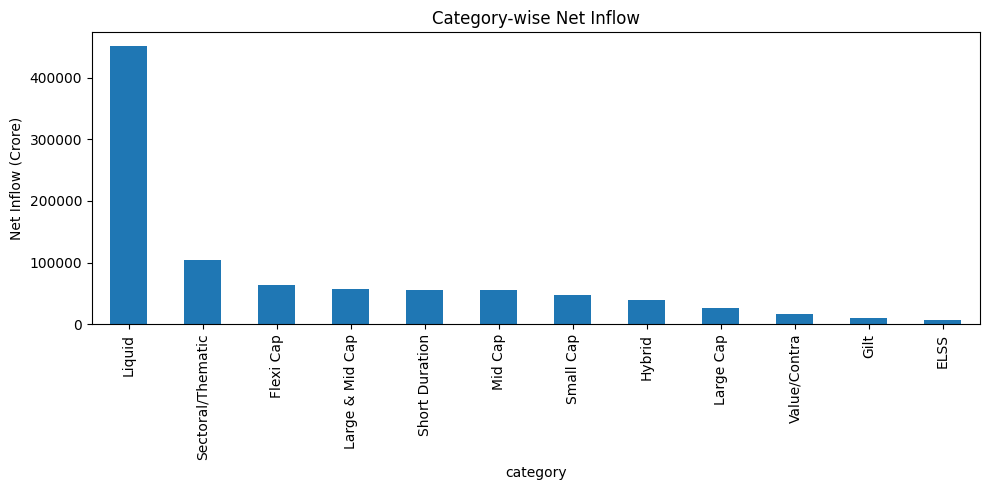

In [27]:
cat_sum = cat.groupby(
    "category"
)["net_inflow_crore"].sum()

cat_sum.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title("Category-wise Net Inflow")
plt.ylabel("Net Inflow (Crore)")

plt.tight_layout()
plt.show()

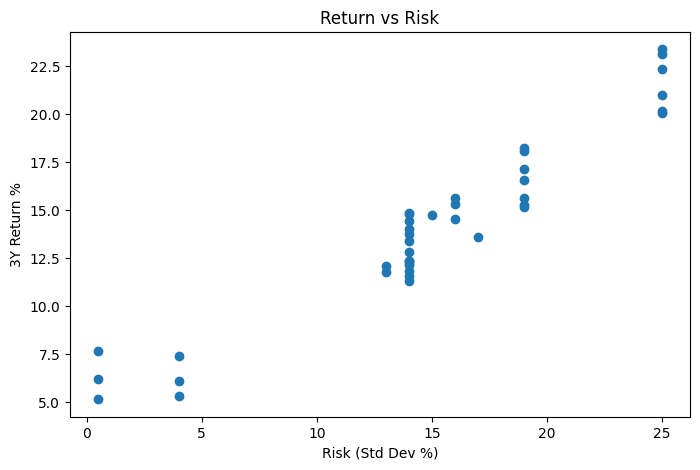

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    perf["std_dev_ann_pct"],
    perf["return_3yr_pct"]
)

plt.xlabel("Risk (Std Dev %)")
plt.ylabel("3Y Return %")

plt.title("Return vs Risk")

plt.show()

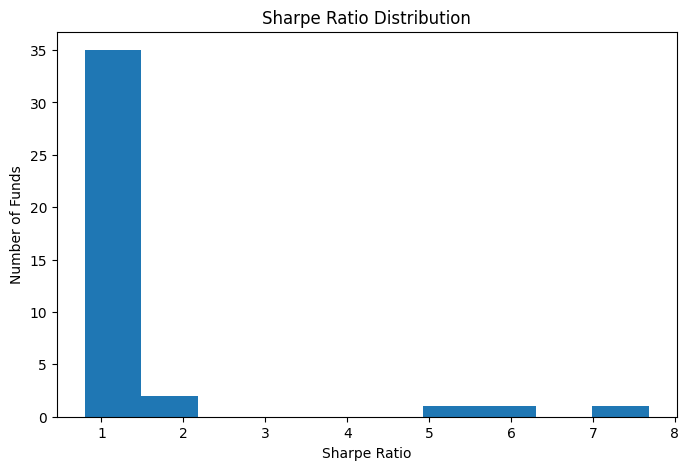

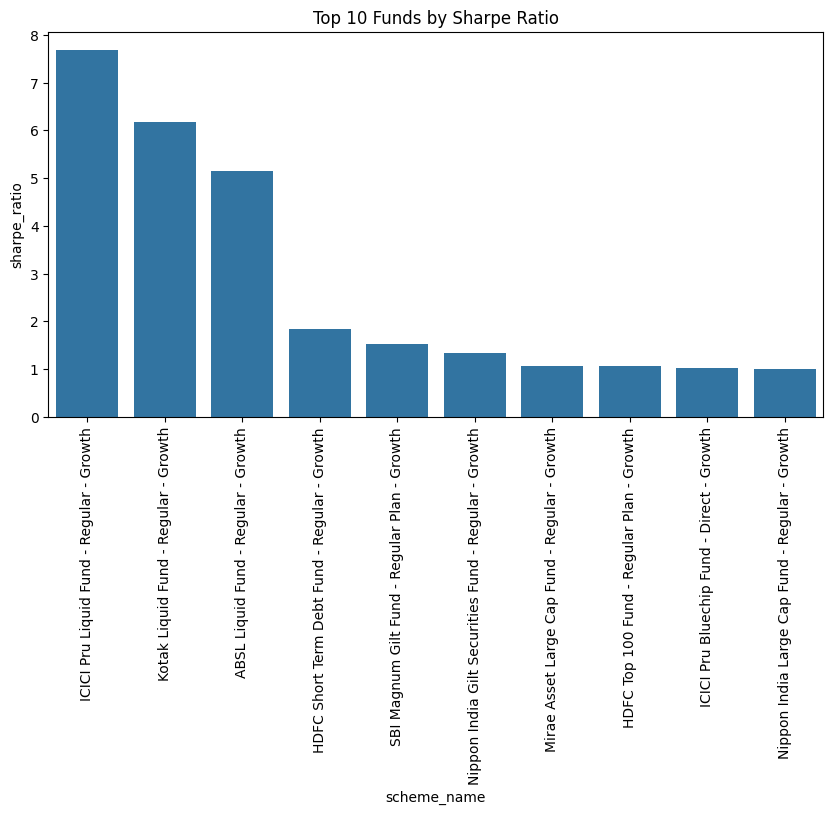

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    perf["sharpe_ratio"],
    bins=10
)

plt.title("Sharpe Ratio Distribution")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.show()

# Sharpe Ratio Analysis



top_sharpe = (
    perf
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)



plt.figure(figsize=(10,5))


sns.barplot(
    data=top_sharpe,
    x="scheme_name",
    y="sharpe_ratio"
)


plt.title(
    "Top 10 Funds by Sharpe Ratio"
)


plt.xticks(
    rotation=90
)


plt.show()

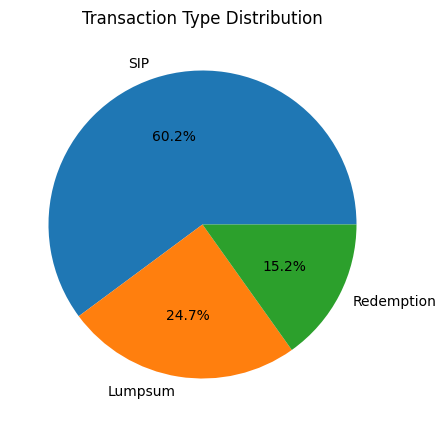

In [30]:
txn["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.show()

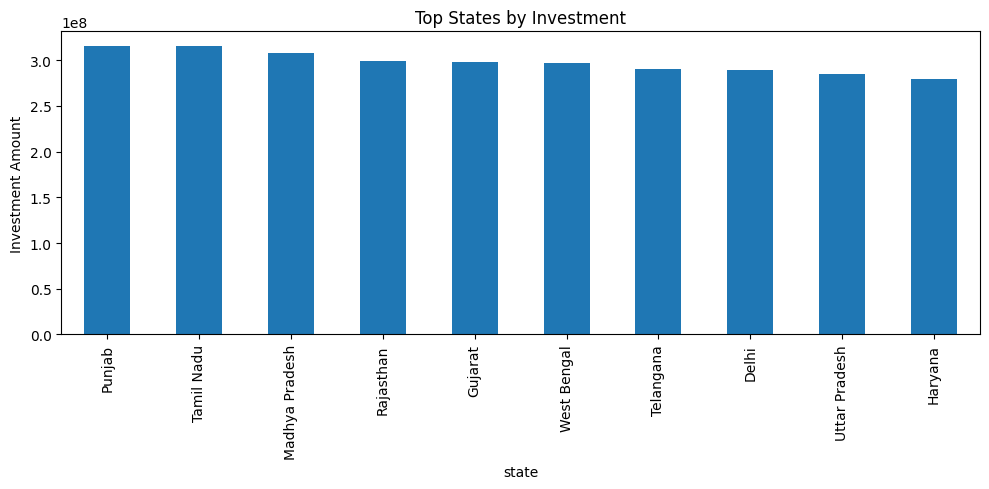

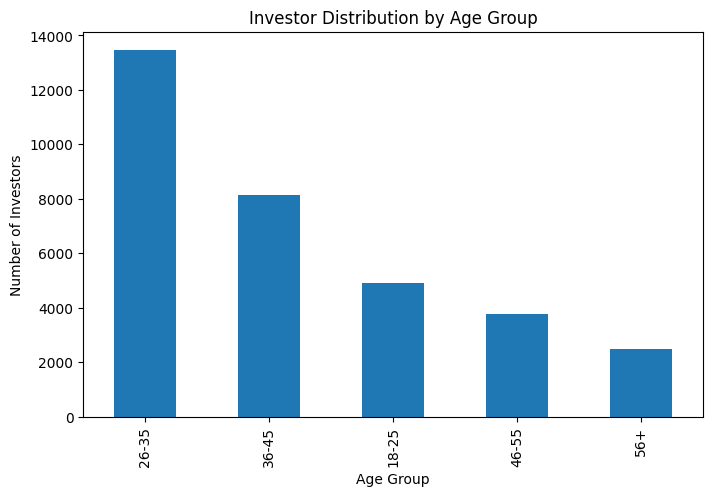

In [46]:
top_states = (
    txn.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top_states.plot(kind="bar")

plt.title("Top States by Investment")
plt.ylabel("Investment Amount")

plt.tight_layout()
plt.show()

# Investment by different Age groups
plt.figure(figsize=(8,5))


txn["age_group"].value_counts().plot(
    kind="bar"
)


plt.title(
    "Investor Distribution by Age Group"
)


plt.xlabel(
    "Age Group"
)


plt.ylabel(
    "Number of Investors"
)


plt.show()

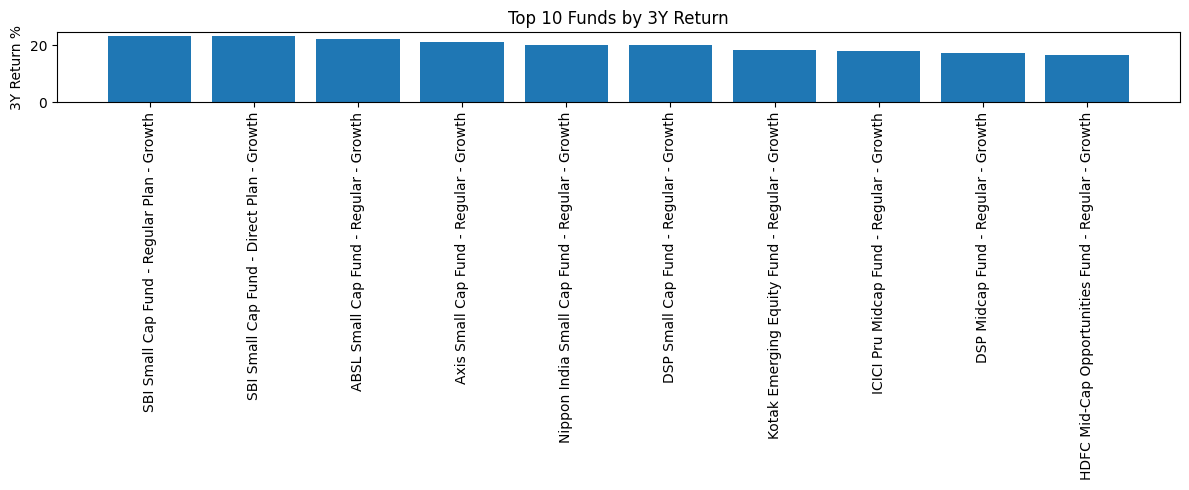

In [42]:
top_funds = perf.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_funds["scheme_name"],
    top_funds["return_3yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3Y Return")
plt.ylabel("3Y Return %")

plt.tight_layout()
plt.show()

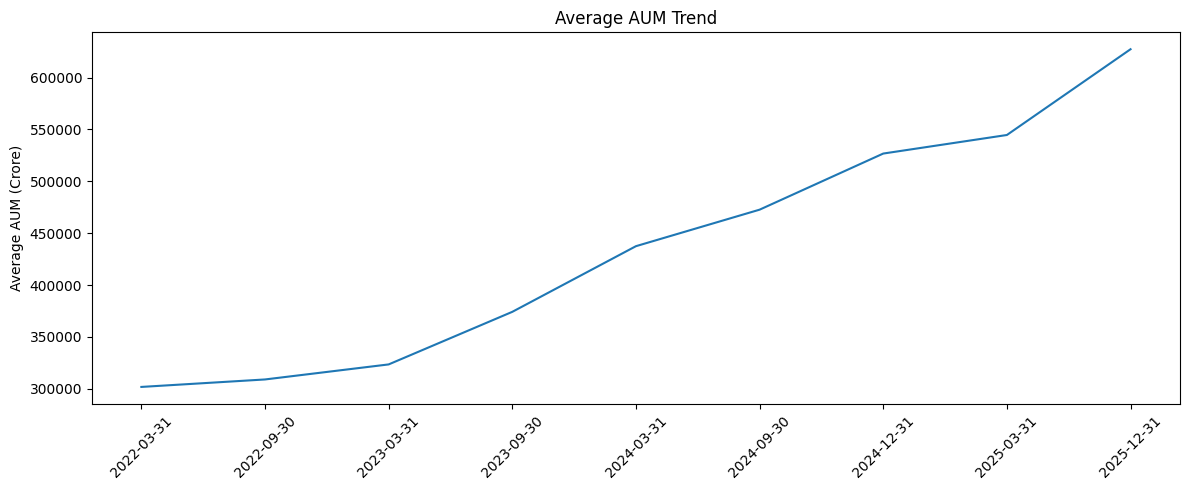

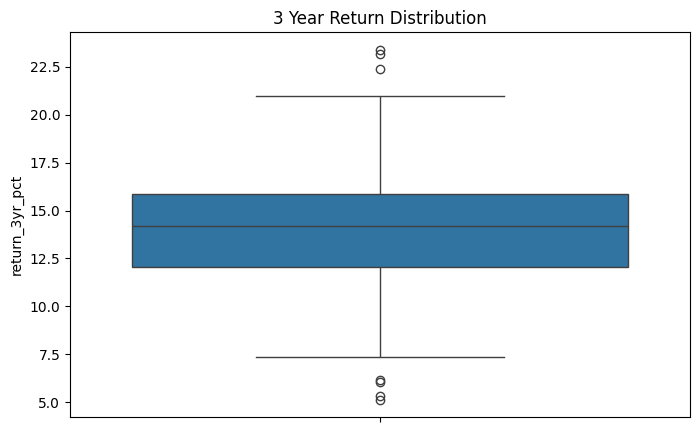

In [44]:
aum_date = aum.groupby(
    "date"
)["aum_crore"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    aum_date.index,
    aum_date.values
)

plt.xticks(rotation=45)

plt.title("Average AUM Trend")
plt.ylabel("Average AUM (Crore)")

plt.tight_layout()
plt.show()

# Return Analysis



plt.figure(figsize=(8,5))


sns.boxplot(
    data=perf,
    y="return_3yr_pct"
)


plt.title(
    "3 Year Return Distribution"
)


plt.show()

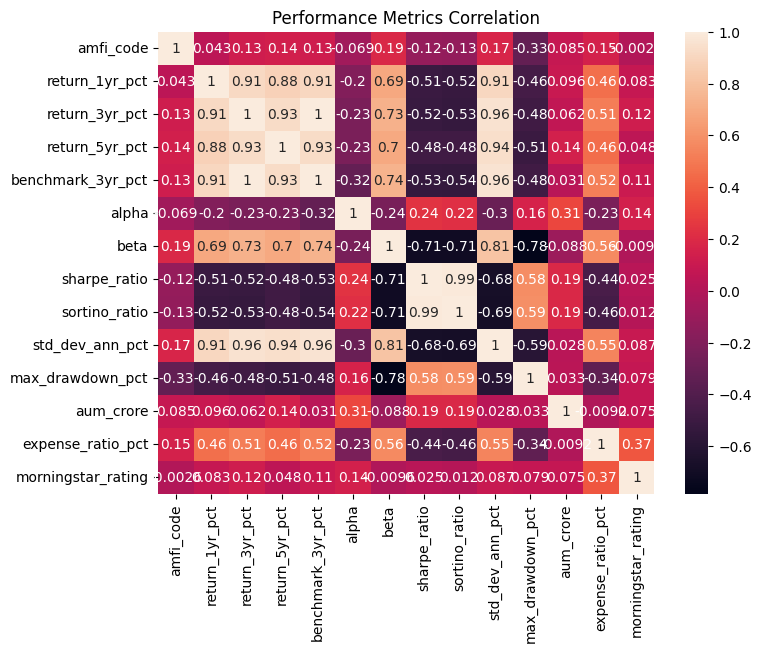

In [54]:

# Correlation Analysis



numeric_data = perf.select_dtypes(
    include=np.number
)



plt.figure(figsize=(8,6))


sns.heatmap(
    numeric_data.corr(),
    annot=True
)


plt.title(
    "Performance Metrics Correlation"
)


plt.show()



# Key EDA Findings

1. SIP inflows showed a strong upward trend from 2022 to 2025, reflecting growing retail participation in mutual funds.

2. December 2025 recorded the highest SIP inflow in the dataset, indicating sustained investor confidence.

3. SBI Mutual Fund maintained one of the highest AUM levels among all fund houses.

4. Equity-oriented schemes contributed the largest share of total folios across the industry.

5. Folio count increased significantly between 2022 and 2025, demonstrating rapid growth in mutual fund adoption.

6. Large Cap and Flexi Cap categories attracted relatively stable inflows compared to thematic funds.

7. Investor participation was concentrated in major states and metropolitan regions.

8. Correlation analysis showed that funds within similar categories tend to move together.

9. Portfolio holdings revealed significant allocation toward sectors such as Financial Services and Information Technology.

10. Fund performance varied considerably across categories, highlighting the importance of diversification and risk-adjusted evaluation.


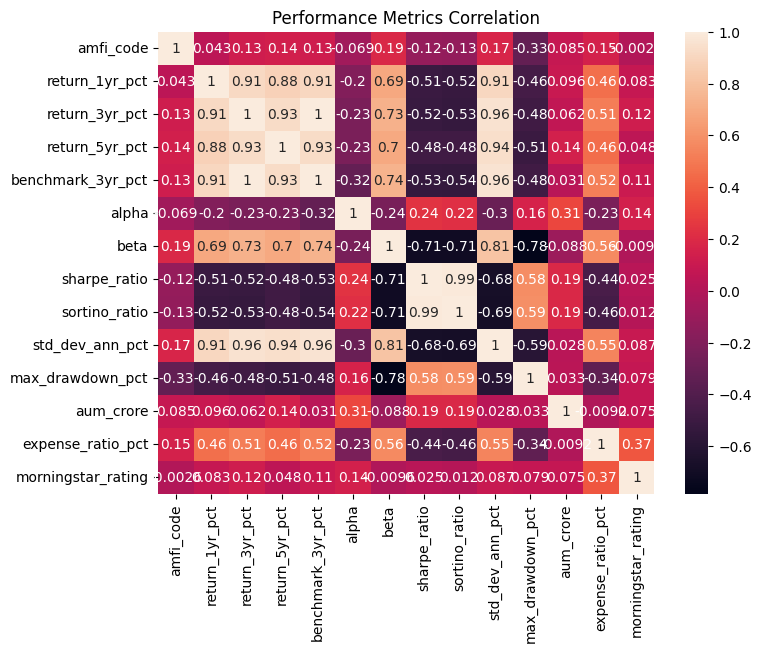

In [53]:

# Correlation Analysis



numeric_data = perf.select_dtypes(
    include=np.number
)



plt.figure(figsize=(8,6))


sns.heatmap(
    numeric_data.corr(),
    annot=True
)


plt.title(
    "Performance Metrics Correlation"
)


plt.show()

